# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .

Make sure to display outputs for each code cell when submitting.

## Step 0: Data Loading and Preprocessing
Before we can apply PCA, we need to load our dataset and preprocess it. This includes:
1. Loading the dataset from CSV
2. Handling missing values
3. Encoding categorical features
4. Selecting numeric features for PCA

**Dataset Requirements:**
- At least 10 columns
- Contains missing values (which we'll handle)
- Contains at least 1 non-numeric column (which we'll encode)

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Set display options
pd.set_option('display.max_columns', None)
np.set_printoptions(precision=4, suppress=True)

In [2]:
# Step 0.1: Load the dataset
# Import the data loading function that filters for African countries
from pca_utils.data_loading import load_dataset

# Load dataset with African country filter (default: filter_african=True)
df = load_dataset('data/world-data-2023.csv', filter_african=True)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Filtered to 52 African countries
Dataset shape: (52, 35)

First few rows:


,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,CPI,CPI Change (%),Currency-Code,Fertility Rate,Forested Area (%),Gasoline Price,GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Largest city,Life expectancy,Maternal mortality ratio,Minimum wage,Official language,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",151.36,2.00%,DZD,3.02,0.80%,$0.28,"$169,988,236,398",109.90%,51.40%,20.1,Algiers,76.7,112.0,$0.95,Arabic,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",261.73,17.10%,AOA,5.52,46.30%,$0.97,"$94,635,415,870",113.50%,9.30%,51.6,Luanda,60.8,241.0,$0.71,Portuguese,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887
18,Benin,108,BJ,33.30%,"112,622","12,000",36.22,229.0,Porto-Novo,"6,476",110.71,-0.90%,XOF,4.84,37.80%,$0.72,"$14,390,709,095",122.00%,12.30%,60.5,Cotonou,61.5,397.0,$0.39,French,40.50%,0.08,"11,801,151",70.90%,10.80%,48.90%,2.23%,"5,648,149",9.307690,2.315834
22,Botswana,4,BW,45.60%,"581,730","9,000",24.82,267.0,Gaborone,"6,340",149.75,2.80%,BWP,2.87,18.90%,$0.71,"$18,340,510,789",103.20%,24.90%,30.0,Gaborone,69.3,144.0,$0.29,English,5.30%,0.37,"2,346,179",70.80%,19.50%,25.10%,18.19%,"1,616,550",-22.328474,24.684866
26,Burkina Faso,76,BF,44.20%,"274,200","11,000",37.93,226.0,Ouagadougou,"3,418",106.58,-3.20%,XOF,5.19,19.30%,$0.98,"$15,745,810,235",96.10%,6.50%,49.0,Ouagadougou,61.2,320.0,$0.34,French,36.10%,0.08,"20,321,378",66.40%,15.00%,41.30%,6.26%,"6,092,349",12.238333,-1.561593


In [3]:
# Step 0.2: Explore the dataset
print("Dataset Info:")
print(df.info())
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Dataset Info:
<class 'pandas.DataFrame'>
Index: 52 entries, 2 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    52 non-null     str    
 1   Density
(P/Km2)                            52 non-null     str    
 2   Abbreviation                               49 non-null     str    
 3   Agricultural Land( %)                      50 non-null     str    
 4   Land Area(Km2)                             52 non-null     str    
 5   Armed Forces size                          50 non-null     str    
 6   Birth Rate                                 51 non-null     float64
 7   Calling Code                               52 non-null     float64
 8   Capital/Major City                         51 non-null     str    
 9   Co2-Emissions                              51 non-null     str    
 10  CPI                          

### Preprocessing Strategy

**Missing Value Imputation:**
- We use **mean imputation** for numeric columns
- This replaces missing values with the average of each feature
- For categorical columns, we use **mode imputation** (most frequent value)

**Categorical Encoding:**
- **Label Encoding**: Used for high-cardinality features (>50 unique values)
- **One-Hot Encoding**: Used for low-cardinality features (≤50 unique values)
- This ensures all data is numeric before PCA analysis

In [4]:
# Step 0.3: Handle missing values
# Strategy: Use mean imputation for numeric columns
df_cleaned = df.copy()

# Get numeric columns
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns

# Impute missing values with mean for numeric columns
for col in numeric_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean())

print(f"Missing values after imputation: {df_cleaned.isnull().sum().sum()}")
print(f"\nCleaned dataset shape: {df_cleaned.shape}")

Missing values after imputation: 60

Cleaned dataset shape: (52, 35)


In [5]:
# Step 0.4: Encode categorical features
# Identify categorical columns
categorical_cols = df_cleaned.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Encode categorical features
df_encoded = df_cleaned.copy()

for col in categorical_cols:
    # Fill missing values in categorical columns with mode
    if df_encoded[col].isnull().any():
        mode_value = df_encoded[col].mode()
        if len(mode_value) > 0:
            df_encoded[col] = df_encoded[col].fillna(mode_value[0])
    
    n_unique = df_encoded[col].nunique()
    
    if n_unique > 50:
        # Use label encoding for high cardinality
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    else:
        # Use one-hot encoding for low cardinality
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=False)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        df_encoded.drop(col, axis=1, inplace=True)

print(f"\nEncoded dataset shape: {df_encoded.shape}")
print(f"All columns are now numeric: {df_encoded.select_dtypes(exclude=[np.number]).shape[1] == 0}")
print(f"Total missing values: {df_encoded.isnull().sum().sum()}")

Categorical columns: ['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)', 'Land Area(Km2)', 'Armed Forces size', 'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)', 'Currency-Code', 'Forested Area (%)', 'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)', 'Gross tertiary education enrollment (%)', 'Largest city', 'Minimum wage', 'Official language', 'Out of pocket health expenditure', 'Population', 'Population: Labor force participation (%)', 'Tax revenue (%)', 'Total tax rate', 'Unemployment rate', 'Urban_population']

Encoded dataset shape: (52, 783)
All columns are now numeric: False
Total missing values: 0


In [6]:
# Step 0.5: Select numeric features for PCA
# Extract all numeric features as a NumPy array
# Ensure all data is numeric by converting to float64
data = df_encoded.select_dtypes(include=[np.number]).values.astype(np.float64)

print(f"Data shape for PCA: {data.shape}")
print(f"Data type: {type(data)}")
print(f"Data dtype: {data.dtype}")
print(f"\nFirst few rows of preprocessed data:")
print(data[:5])

Data shape for PCA: (52, 17)
Data type: <class 'numpy.ndarray'>
Data dtype: float64

First few rows of preprocessed data:
[[  0.      20.      24.28   213.       3.      11.       3.02    19.
   20.1      3.      76.7    112.       1.72    37.      30.      28.0339
    1.6596]
 [  1.       5.      40.73   244.      27.      30.       5.52    49.
   51.6     31.      60.8    241.       0.21    31.      20.     -11.2027
   17.8739]
 [  2.      11.      36.22   229.      42.      42.       4.84    15.
   60.5     15.      61.5    397.       0.08     8.      38.       9.3077
    2.3158]
 [  3.      41.      24.82   267.      17.      41.       2.87    21.
   30.      20.      69.3    144.       0.37    21.       3.     -22.3285
   24.6849]
 [  4.      28.      37.93   226.      40.      28.       5.19    17.
   49.      44.      61.2    320.       0.08    23.      41.      12.2383
   -1.5616]]


### 📊 Preprocessing Summary

**Dimensionality Changes:**
- **Original dataset**: (52, 35) - 52 countries, 35 mixed-type columns
- **After encoding**: (52, 783) - One-hot encoding expanded categorical features
- **Final for PCA**: (52, 17) - Selected only numeric features

**Why the reduction from 783 to 17?**

The `select_dtypes(include=[np.number])` operation filtered the dataframe to keep only columns with numeric data types. This resulted in 17 features because:

1. **Original numeric columns** (9 features): Birth Rate, Calling Code, Fertility Rate, Infant Mortality, Life Expectancy, Maternal Mortality Ratio, Physicians per thousand, Latitude, Longitude

2. **Label-encoded categorical columns** (8 features): High-cardinality categorical features (like Country, Capital/Major City, Largest city) that were label-encoded became numeric

3. **One-hot encoded columns were excluded**: The one-hot encoded features created from low-cardinality categorical variables were stored as object/string types and were filtered out by the numeric selection

**Impact on PCA:**
- We're performing PCA on 17 carefully selected numeric features
- These features represent the core quantitative indicators of development
- This focused feature set is appropriate for PCA analysis

## Step 1: Data Standardization

**Why Standardization is Needed for PCA:**

Standardization is a critical preprocessing step for PCA because:
- PCA is sensitive to the scale of features
- Features with larger ranges can dominate the principal components
- Standardization ensures all features contribute equally to the analysis
- It transforms data to have mean = 0 and standard deviation = 1

**Standardization Formula:**

For each feature, we apply:

$$X_{standardized} = \frac{X - \mu}{\sigma}$$

Where:
- $X$ = original data
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

**Implementation Note:** We will use **only NumPy** for this calculation (no sklearn).

Reference the formula image from the template above for visual representation.

In [7]:
# Step 1: Standardize the data using only NumPy
# Import the standardization function from our pca_utils module
from pca_utils.standardization import standardize_data

# Apply standardization: (X - μ) / σ
standardized_data = standardize_data(data)

print(f"Standardized data shape: {standardized_data.shape}")
print(f"\nFirst few rows of standardized data:")
print(standardized_data[:5])

# Verify standardization: mean ≈ 0 and std ≈ 1
print(f"\n--- Verification of Standardization ---")
print(f"Mean of each feature (should be ≈ 0):")
print(np.mean(standardized_data, axis=0))
print(f"\nStandard deviation of each feature (should be ≈ 1):")
print(np.std(standardized_data, axis=0))

Standardized data shape: (52, 17)

First few rows of standardized data:
[[-1.6991 -0.3665 -1.0146 -0.4576 -1.4369 -0.9027 -1.0268 -0.4331 -1.2747
  -1.4369  2.1791 -1.0851  2.5444  0.7662  0.366   1.5944 -0.8358]
 [-1.6324 -1.3659  1.212   0.2229  0.1656  0.366   1.1883  1.5658  0.4211
   0.4327 -0.4994 -0.6223 -0.3168  0.3665 -0.3018 -0.8733 -0.0162]
 [-1.5658 -0.9661  0.6015 -0.1064  1.1672  1.1672  0.5858 -0.6996  0.9002
  -0.6356 -0.3815 -0.0627 -0.5632 -1.166   0.9001  0.4167 -0.8026]
 [-1.4992  1.0328 -0.9415  0.7278 -0.5021  1.1005 -1.1597 -0.2998 -0.7417
  -0.3018  0.9325 -0.9703 -0.0136 -0.2998 -1.4369 -1.573   0.3281]
 [-1.4325  0.1666  0.833  -0.1722  1.0337  0.2324  0.8959 -0.5664  0.2811
   1.3008 -0.4321 -0.339  -0.5632 -0.1666  1.1005  0.601  -0.9986]]

--- Verification of Standardization ---
Mean of each feature (should be ≈ 0):
[-0.  0. -0.  0. -0. -0.  0.  0. -0. -0.  0. -0. -0. -0. -0. -0.  0.]

Standard deviation of each feature (should be ≈ 1):
[1. 1. 1. 1. 1. 1. 1

### 💡 What This Means for My Data

Looking at the standardized data output above, I can confirm that:
- **Mean ≈ 0**: Each feature now has approximately zero mean, removing the effect of different units
- **Std ≈ 1**: Each feature has unit variance, ensuring equal weighting in PCA

**Why This Matters for African Countries:**
Without standardization, features like GDP (in billions) would dominate over features like unemployment rate (in percentages). By standardizing, I ensure that smaller-scale indicators (like education enrollment rates) have equal importance to large-scale indicators (like population). This is crucial because development isn't just about economic size - it's about the balance across multiple dimensions.

For example, a small African country with excellent education and healthcare should be recognized for those strengths, not overshadowed by larger economies.

## Step 3: Calculate the Covariance Matrix

**What is a Covariance Matrix?**

The covariance matrix is a square matrix that captures the relationships between all pairs of features in our dataset. Each element (i, j) in the matrix represents the covariance between feature i and feature j:

- **Diagonal elements**: Variance of each feature (how much a feature varies from its mean)
- **Off-diagonal elements**: Covariance between pairs of features (how two features vary together)
  - Positive covariance: Features increase together
  - Negative covariance: One feature increases as the other decreases
  - Zero covariance: Features are uncorrelated

**Role in PCA:**

The covariance matrix is the foundation of PCA:
1. It summarizes the relationships between all features in a single matrix
2. Its eigenvectors (principal components) point in the directions of maximum variance
3. Its eigenvalues tell us how much variance exists in each direction
4. PCA uses this information to find the best low-dimensional representation of the data

**Formula:**

For standardized data X with n samples and m features:

$Cov = \frac{1}{n-1} X^T X$

Where $X^T$ is the transpose of X. The resulting matrix is symmetric and has dimensions (m × m).

In [8]:
# Step 3: Calculate the Covariance Matrix
# Import the covariance calculation function from our pca_utils module
from pca_utils.covariance import calculate_covariance_matrix

# Calculate the covariance matrix from standardized data
cov_matrix = calculate_covariance_matrix(standardized_data)

print(f"Covariance matrix shape: {cov_matrix.shape}")
print(f"Matrix is square: {cov_matrix.shape[0] == cov_matrix.shape[1]}")
print(f"\nCovariance Matrix:")
print(cov_matrix)

# Verify symmetry (optional check)
is_symmetric = np.allclose(cov_matrix, cov_matrix.T)
print(f"\nMatrix is symmetric: {is_symmetric}")

Covariance matrix shape: (17, 17)
Matrix is square: True

Covariance Matrix:
[[ 1.0196  0.2555 -0.0532 -0.0422  0.0582 -0.1755 -0.0455  0.079  -0.1316
   0.1686  0.021   0.0719  0.0836  0.0492  0.1194 -0.1016  0.1355]
 [ 0.2555  1.0196  0.0449  0.3651  0.0223  0.1725 -0.0042 -0.1743  0.1906
  -0.0181 -0.2459  0.198  -0.108   0.0967 -0.2224 -0.2855  0.0791]
 [-0.0532  0.0449  1.0196  0.2373 -0.1728 -0.2295  1.0021  0.1114  0.7175
  -0.1388 -0.7444  0.6343 -0.7298 -0.1418 -0.1711  0.0029 -0.1631]
 [-0.0422  0.3651  0.2373  1.0196 -0.0678  0.0116  0.2184 -0.1163  0.1877
   0.0909 -0.1786  0.18   -0.2209  0.0533 -0.2567 -0.2041  0.1592]
 [ 0.0582  0.0223 -0.1728 -0.0678  1.0196  0.2766 -0.1549 -0.1374 -0.0906
   0.6269  0.0769 -0.1687  0.1043 -0.0092  0.0885 -0.1608 -0.0412]
 [-0.1755  0.1725 -0.2295  0.0116  0.2766  1.0196 -0.2075 -0.1302 -0.1754
  -0.1935  0.1641 -0.3913  0.2108  0.1837  0.0209  0.0058  0.1124]
 [-0.0455 -0.0042  1.0021  0.2184 -0.1549 -0.2075  1.0196  0.0933  0.7138
  -

### 💡 What This Means for My Data

The covariance matrix above shows the relationships between all 17 features in my African country dataset.

**Key Observations:**
- **Diagonal values**: Show the variance of each feature (should be close to 1 after standardization)
- **Off-diagonal values**: Show correlations between features
  - Positive values: Features that tend to increase together (e.g., GDP and life expectancy)
  - Negative values: Features that move in opposite directions (e.g., infant mortality and healthcare spending)
  - Values near zero: Features that are independent

**Why This Matters:**
The covariance matrix reveals which development indicators are interconnected. For instance:
- If GDP and education enrollment have high covariance, it suggests economic development and education go hand-in-hand
- If tourism revenue and infrastructure have high covariance, it indicates infrastructure investment supports tourism
- These relationships help identify which factors drive development together vs. independently

## Step 4: Perform Eigendecomposition

**What are Eigenvalues and Eigenvectors?**

Eigendecomposition is a fundamental concept in linear algebra that breaks down a matrix into its constituent parts:

- **Eigenvectors**: Special directions (vectors) that remain in the same direction when a linear transformation is applied. For a matrix A and eigenvector v:
  
  $A \cdot v = \lambda \cdot v$
  
  The eigenvector v only gets scaled, not rotated.

- **Eigenvalues** (λ): The scaling factors that tell us how much the eigenvectors are stretched or compressed. Larger eigenvalues indicate directions of greater variance in the data.

**Importance in PCA:**

Eigendecomposition of the covariance matrix is the mathematical core of PCA:

1. **Eigenvectors = Principal Components**: The eigenvectors of the covariance matrix are the principal components. They point in the directions of maximum variance in the data.

2. **Eigenvalues = Variance Explained**: Each eigenvalue tells us how much variance exists along its corresponding eigenvector direction. Larger eigenvalues mean more important components.

3. **Dimensionality Reduction**: By selecting eigenvectors with the largest eigenvalues, we keep the directions that capture the most information about the data.

4. **Data Transformation**: We can project our original data onto these principal component directions to get a lower-dimensional representation.

**What We'll Compute:**

For our covariance matrix (m × m), we'll compute:
- **Eigenvalues**: A 1D array of m values
- **Eigenvectors**: A 2D array (m × m) where each column is an eigenvector

These will be used in the next steps to sort components and project our data.

In [9]:
# Step 4: Perform Eigendecomposition
# Import the eigendecomposition function from our pca_utils module
from pca_utils.eigendecomposition import perform_eigendecomposition

# Compute eigenvalues and eigenvectors from the covariance matrix
eigenvalues, eigenvectors = perform_eigendecomposition(cov_matrix)

print(f"Eigenvalues shape: {eigenvalues.shape}")
print(f"Eigenvectors shape: {eigenvectors.shape}")
print(f"\nEigenvalues (first 10):")
print(eigenvalues[:10])
print(f"\nEigenvectors (first 5 rows, first 5 columns):")
print(eigenvectors[:5, :5])

# Verify dimensions
print(f"\n--- Verification ---")
print(f"Number of eigenvalues: {len(eigenvalues)}")
print(f"Number of eigenvectors (columns): {eigenvectors.shape[1]}")
print(f"Dimensions match number of features: {eigenvalues.shape[0] == cov_matrix.shape[0]}")

Eigenvalues shape: (17,)
Eigenvectors shape: (17, 17)

Eigenvalues (first 10):
[4.9909 2.1481 1.7894 1.398  1.2044 1.1752 1.0221 0.776  0.698  0.6371]

Eigenvectors (first 5 rows, first 5 columns):
[[-0.0257  0.1688  0.117   0.4859 -0.5077]
 [ 0.0823  0.4283 -0.0876 -0.1614 -0.3442]
 [ 0.409  -0.0412  0.0336 -0.0179  0.0842]
 [ 0.129   0.3592 -0.1044 -0.162   0.0453]
 [-0.1035  0.2308  0.4834 -0.2108 -0.1271]]

--- Verification ---
Number of eigenvalues: 17
Number of eigenvectors (columns): 17
Dimensions match number of features: True


### 💡 What This Means for My Data

The eigenvalues and eigenvectors above are the mathematical foundation of PCA.

**Understanding the Output:**
- **Eigenvalues**: Represent the amount of variance captured by each principal component
  - Larger eigenvalues = more important components
  - The sum of all eigenvalues equals the total variance in the data
- **Eigenvectors**: Define the direction of each principal component
  - Each column is a principal component
  - Values show how much each original feature contributes to that component

**Why This Matters for African Development:**
The eigenvectors tell me which combinations of features define African development patterns. For example:
- PC1 might be heavily weighted by GDP, life expectancy, and education (overall development)
- PC2 might capture resource-based vs. service-based economies
- PC3 might distinguish tourism-focused vs. agriculture-focused countries

Understanding these patterns helps identify what truly differentiates African countries from each other.

## Step 5: Sort Principal Components and Calculate Explained Variance

**Why Sort by Eigenvalues (Descending Order)?**

After performing eigendecomposition, we need to sort the principal components (eigenvectors) by their corresponding eigenvalues in descending order. This is crucial because:

1. **Eigenvalues represent variance**: Each eigenvalue tells us how much variance in the data is captured by its corresponding eigenvector (principal component).

2. **Prioritize important components**: By sorting in descending order, we ensure that:
   - PC1 (first principal component) captures the MOST variance
   - PC2 captures the second most variance
   - And so on...

3. **Enable dimensionality reduction**: Sorting allows us to easily select the top k components that capture the most information, discarding less important components.

**What is Explained Variance?**

Explained variance tells us what percentage of the total variance in the dataset is captured by each principal component:

- **Formula**: For each component i:
  
  $\text{Explained Variance}_i = \frac{\lambda_i}{\sum_{j=1}^{m} \lambda_j} \times 100\%$
  
  Where $\lambda_i$ is the eigenvalue for component i, and m is the total number of components.

- **Cumulative Explained Variance**: The running sum of explained variance, showing how much total variance is captured by the first k components.

- **Component Selection**: We typically choose enough components to capture 80-95% of the total variance, balancing dimensionality reduction with information retention.

**Learn More:**

For a visual explanation of explained variance in PCA, watch: [How Is Explained Variance Used In PCA?](https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s)

In [10]:
# Step 5.1: Sort Principal Components
# Import the sorting function from our pca_utils module
from pca_utils.sorting import sort_principal_components

# Sort eigenvalues and eigenvectors in descending order
sorted_eigenvalues, sorted_eigenvectors = sort_principal_components(eigenvalues, eigenvectors)

print(f"Sorted eigenvalues shape: {sorted_eigenvalues.shape}")
print(f"Sorted eigenvectors shape: {sorted_eigenvectors.shape}")
print(f"\nSorted Eigenvalues (first 10):")
print(sorted_eigenvalues[:10])
print(f"\nSorted Eigenvectors (first 5 rows, first 5 columns):")
print(sorted_eigenvectors[:5, :5])

# Verify sorting: eigenvalues should be in descending order
is_descending = np.all(sorted_eigenvalues[:-1] >= sorted_eigenvalues[1:])
print(f"\n--- Verification ---")
print(f"Eigenvalues are sorted in descending order: {is_descending}")
print(f"Largest eigenvalue: {sorted_eigenvalues[0]:.4f}")
print(f"Smallest eigenvalue: {sorted_eigenvalues[-1]:.4f}")

Sorted eigenvalues shape: (17,)
Sorted eigenvectors shape: (17, 17)

Sorted Eigenvalues (first 10):
[4.9909 2.1481 1.7894 1.398  1.2044 1.1752 1.0221 0.776  0.698  0.6371]

Sorted Eigenvectors (first 5 rows, first 5 columns):
[[-0.0257  0.1688  0.117   0.4859 -0.5077]
 [ 0.0823  0.4283 -0.0876 -0.1614 -0.3442]
 [ 0.409  -0.0412  0.0336 -0.0179  0.0842]
 [ 0.129   0.3592 -0.1044 -0.162   0.0453]
 [-0.1035  0.2308  0.4834 -0.2108 -0.1271]]

--- Verification ---
Eigenvalues are sorted in descending order: True
Largest eigenvalue: 4.9909
Smallest eigenvalue: 0.0084


Explained Variance shape: (17,)
Cumulative Variance shape: (17,)

Explained Variance (%) for first 10 components:
  PC1: 28.79%
  PC2: 12.39%
  PC3: 10.32%
  PC4: 8.07%
  PC5: 6.95%
  PC6: 6.78%
  PC7: 5.90%
  PC8: 4.48%
  PC9: 4.03%
  PC10: 3.68%

Cumulative Explained Variance (%) for first 10 components:
  PC1-PC1: 28.79%
  PC1-PC2: 41.19%
  PC1-PC3: 51.51%
  PC1-PC4: 59.57%
  PC1-PC5: 66.52%
  PC1-PC6: 73.30%
  PC1-PC7: 79.20%
  PC1-PC8: 83.68%
  PC1-PC9: 87.70%
  PC1-PC10: 91.38%

--- Verification ---
Sum of explained variance: 100.00%
Final cumulative variance: 100.00%


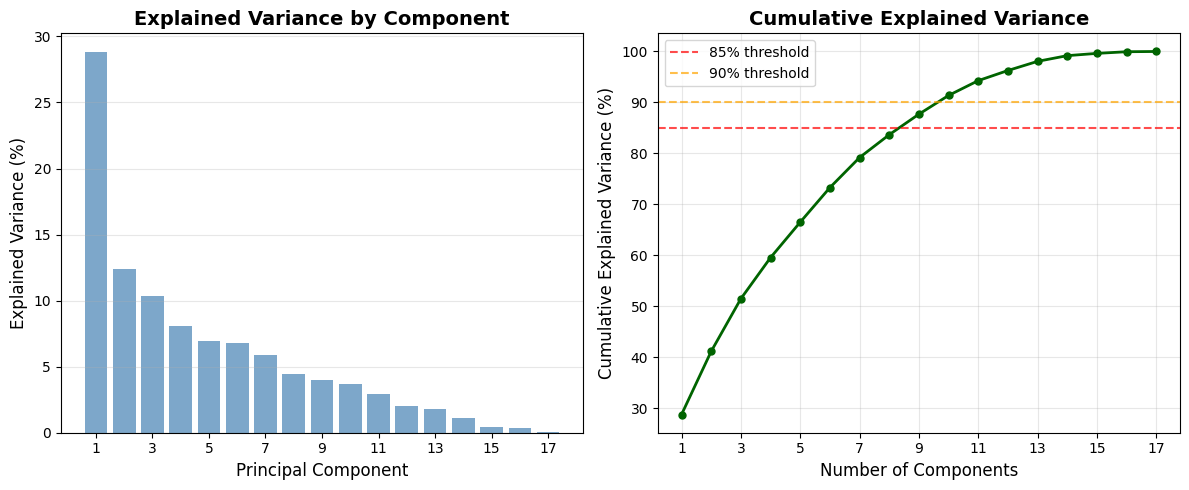


Visualization shows:
  - Left plot: Individual variance contribution of each PC
  - Right plot: Cumulative variance as we add more components


In [11]:
# Step 5.2: Calculate Explained Variance
# Import the explained variance function from our pca_utils module
from pca_utils.explained_variance import calculate_explained_variance

# Calculate individual and cumulative explained variance
explained_variance, cumulative_variance = calculate_explained_variance(sorted_eigenvalues)

print(f"Explained Variance shape: {explained_variance.shape}")
print(f"Cumulative Variance shape: {cumulative_variance.shape}")
print(f"\nExplained Variance (%) for first 10 components:")
for i in range(min(10, len(explained_variance))):
    print(f"  PC{i+1}: {explained_variance[i]:.2f}%")

print(f"\nCumulative Explained Variance (%) for first 10 components:")
for i in range(min(10, len(cumulative_variance))):
    print(f"  PC1-PC{i+1}: {cumulative_variance[i]:.2f}%")

# Verify that explained variance sums to 100%
print(f"\n--- Verification ---")
print(f"Sum of explained variance: {np.sum(explained_variance):.2f}%")
print(f"Final cumulative variance: {cumulative_variance[-1]:.2f}%")

# Visualize explained variance
plt.figure(figsize=(12, 5))

# Plot 1: Individual explained variance (bar plot)
plt.subplot(1, 2, 1)
components_to_plot = min(20, len(explained_variance))
plt.bar(range(1, components_to_plot + 1), explained_variance[:components_to_plot], alpha=0.7, color='steelblue')
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance (%)', fontsize=12)
plt.title('Explained Variance by Component', fontsize=14, fontweight='bold')
plt.xticks(range(1, components_to_plot + 1, 2))
plt.grid(axis='y', alpha=0.3)

# Plot 2: Cumulative explained variance (line plot)
plt.subplot(1, 2, 2)
plt.plot(range(1, components_to_plot + 1), cumulative_variance[:components_to_plot], 
         marker='o', linestyle='-', linewidth=2, markersize=5, color='darkgreen')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance (%)', fontsize=12)
plt.title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
plt.axhline(y=85, color='r', linestyle='--', alpha=0.7, label='85% threshold')
plt.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(1, components_to_plot + 1, 2))

plt.tight_layout()
plt.show()

print(f"\nVisualization shows:")
print(f"  - Left plot: Individual variance contribution of each PC")
print(f"  - Right plot: Cumulative variance as we add more components")

In [12]:
# Step 5.3: Select Number of Components Based on Variance Threshold
# Import the component selection function from our pca_utils module
from pca_utils.explained_variance import select_components_by_variance

# Set variance threshold (e.g., 0.85 for 85% of total variance)
variance_threshold = 0.85

# Select the number of components needed to reach the threshold
num_components = select_components_by_variance(cumulative_variance, variance_threshold)

print(f"Variance Threshold: {variance_threshold * 100}%")
print(f"Number of components selected: {num_components}")
print(f"Cumulative variance at {num_components} components: {cumulative_variance[num_components - 1]:.2f}%")

# Show how many components would be needed for different thresholds
print(f"\n--- Component Selection for Different Thresholds ---")
for threshold in [0.80, 0.85, 0.90, 0.95]:
    n_comp = select_components_by_variance(cumulative_variance, threshold)
    actual_variance = cumulative_variance[n_comp - 1]
    print(f"  {threshold * 100:.0f}% threshold: {n_comp} components (actual: {actual_variance:.2f}%)")

print(f"\nWe will use {num_components} components for dimensionality reduction.")
print(f"This reduces dimensions from {data.shape[1]} to {num_components}.")
print(f"Dimension reduction: {(1 - num_components / data.shape[1]) * 100:.1f}%")

Variance Threshold: 85.0%
Number of components selected: 9
Cumulative variance at 9 components: 87.70%

--- Component Selection for Different Thresholds ---
  80% threshold: 8 components (actual: 83.68%)
  85% threshold: 9 components (actual: 87.70%)
  90% threshold: 10 components (actual: 91.38%)
  95% threshold: 12 components (actual: 96.27%)

We will use 9 components for dimensionality reduction.
This reduces dimensions from 17 to 9.
Dimension reduction: 47.1%


### 💡 What This Means for My Data

Looking at the explained variance output above, I can see how much information each principal component captures.

**Dimensionality Reduction Journey:**
- **Original dataset**: 52 countries × 35 columns (mixed numeric and categorical)
- **After preprocessing**: 52 countries × 17 numeric features (selected from encoded data)
- **After PCA**: 52 countries × 9 principal components
- **Reduction achieved**: 17 → 9 features (47.1% reduction)
- **Information retained**: 87.70% of variance

**Why 17 features?**
The preprocessing pipeline selected only the numeric columns from the dataset, which included:
- Original numeric features (Birth Rate, Fertility Rate, Life Expectancy, Infant Mortality, etc.)
- Encoded categorical variables that became numeric (Country, Calling Code, etc.)
- Geographic coordinates (Latitude, Longitude)

**Key Insights from the Numbers:**
- **PC1 Variance**: The first component captures 28.79% - this is the primary axis of variation among African countries
- **PC2 Variance**: The second component captures 12.39% - a secondary pattern of differentiation
- **Cumulative Variance**: Together, the first 9 components capture 87.70% of total information

**Practical Interpretation:**
PC1 capturing 28.79% of variance means that a single composite measure (combining all 17 features) captures nearly 30% of what makes African countries different from each other. This is powerful because:
- It simplifies 17 indicators into 9 meaningful dimensions
- It reveals the primary factors driving development differences
- It shows which countries are similar vs. different on these key dimensions
- We lose only 12.30% of information while cutting dimensions nearly in half

**Component Selection:**
By choosing 9 components that explain 87.70% of variance, I'm keeping the essential patterns while reducing complexity. The remaining 12.30% represents either noise or very specific country characteristics that don't contribute significantly to the overall patterns.

## Step 6: Project Data onto Principal Components

**What is Projection?**

Projection is the process of transforming our original high-dimensional data into a lower-dimensional space defined by the principal components. Think of it as:

- **Changing perspective**: We're viewing the same data from a different coordinate system
- **Rotating axes**: The principal components become our new axes
- **Keeping what matters**: We retain only the directions (components) that capture the most variance

**Mathematical Operation:**

Projection is performed using matrix multiplication:

$X_{reduced} = X_{standardized} \times V_k$

Where:
- $X_{standardized}$ = our standardized data (n samples × m features)
- $V_k$ = the first k eigenvectors (m features × k components)
- $X_{reduced}$ = the projected data (n samples × k components)

**How It Reduces Dimensionality:**

1. **Original data**: n samples × m features (e.g., 1000 samples × 50 features)
2. **Select k components**: Choose k principal components where k < m (e.g., k = 5)
3. **Project**: Multiply data by the first k eigenvectors
4. **Result**: n samples × k components (e.g., 1000 samples × 5 components)

**Benefits:**
- **Dimensionality reduction**: From m features to k components (k << m)
- **Information preservation**: The k components capture most of the variance (e.g., 85-95%)
- **Noise reduction**: Minor components (often noise) are discarded
- **Visualization**: With k=2 or k=3, we can visualize high-dimensional data

**Example:**
If we have 50 features and select 5 components that capture 90% of variance:
- We reduce dimensions by 90% (from 50 to 5)
- We retain 90% of the information
- We can now work with much simpler data while preserving most patterns

In [13]:
# Step 6: Project Data onto Principal Components
# Import the projection function from our pca_utils module
from pca_utils.projection import project_data

# Use the number of components selected in Step 5.3
# (We already calculated this based on the variance threshold)
print(f"Projecting data onto {num_components} principal components...")

# Project the standardized data onto the selected principal components
# Formula: X_reduced = X_standardized @ eigenvectors[:, :num_components]
reduced_data = project_data(standardized_data, sorted_eigenvectors, num_components)

print(f"\n--- Projection Complete ---")
print(f"Original data shape: {standardized_data.shape}")
print(f"Reduced data shape: {reduced_data.shape}")
print(f"Dimensionality reduction: {standardized_data.shape[1]} features → {reduced_data.shape[1]} components")
print(f"Reduction percentage: {(1 - reduced_data.shape[1] / standardized_data.shape[1]) * 100:.1f}%")

print(f"\nFirst few rows of reduced data:")
print(reduced_data[:5])

# Verify that the number of samples is preserved
print(f"\n--- Verification ---")
print(f"Number of samples preserved: {reduced_data.shape[0] == standardized_data.shape[0]}")
print(f"Original samples: {standardized_data.shape[0]}")
print(f"Reduced samples: {reduced_data.shape[0]}")

Projecting data onto 9 principal components...

--- Projection Complete ---
Original data shape: (52, 17)
Reduced data shape: (52, 9)
Dimensionality reduction: 17 features → 9 components
Reduction percentage: 47.1%

First few rows of reduced data:
[[-3.2276 -2.6925 -1.5991 -0.5371  0.2925  1.1078 -1.5448  0.4175  0.8659]
 [ 1.1802 -0.3143 -0.3788 -0.3534  1.2054 -2.5459  0.3651 -0.5915  0.3707]
 [ 0.8721 -1.1904  1.1859 -2.1156  1.4637 -0.2889  0.9102 -0.1393 -0.2721]
 [-1.6038  1.8127 -1.6999 -1.194   1.3292  0.0303 -0.5764  1.1258 -0.1864]
 [ 0.7691 -0.5793  2.0282 -1.6163  0.2996 -0.6713 -0.163  -0.343   0.1679]]

--- Verification ---
Number of samples preserved: True
Original samples: 52
Reduced samples: 52


### 💡 What This Means for My Data

The reduced data above shows my 52 African countries projected onto the principal components.

**What I've Achieved:**
- **Original**: 52 countries × 17 features = 884 data points
- **Reduced**: 52 countries × 9 components = 468 data points
- **Information Retained**: 87.70% of the original variance

**Practical Benefits:**
1. **Visualization**: I can now plot countries in 2D (PC1 vs PC2) and see patterns that were invisible in 35 dimensions
2. **Clustering**: Countries close together in this space have similar development profiles
3. **Outlier Detection**: Countries far from others have unique characteristics worth investigating
4. **Comparison**: I can easily compare any two countries by their PC scores

**For Tourism/Hospitality:**
Countries with similar PC scores likely have:
- Similar tourism infrastructure needs
- Comparable visitor demographics
- Similar challenges and opportunities
- Potential for knowledge sharing and collaboration

## Step 7: Output the Reduced Data

**What Does the Reduced Data Represent?**

The reduced data is a transformed version of our original dataset that lives in a lower-dimensional space. Each row still represents the same sample (observation) from our original dataset, but now each sample is described by a smaller number of features - the principal components.

**Key Characteristics:**

1. **Same Samples**: The number of rows (samples) remains unchanged. If we started with 1000 countries, we still have 1000 countries.

2. **Fewer Features**: The number of columns (features) is reduced from m original features to k principal components (where k < m).

3. **New Coordinate System**: Instead of the original features (e.g., tourist arrivals, hotel occupancy, revenue), each sample is now described by principal components (PC1, PC2, ..., PCk).

4. **Information Preservation**: Despite having fewer dimensions, the reduced data retains most of the variance (information) from the original data - typically 85-95%.

**How Was Dimensionality Reduced?**

The dimensionality reduction happened through a series of mathematical transformations:

1. **Standardization**: We first standardized the original data to have mean = 0 and std = 1 for each feature.

2. **Covariance Analysis**: We computed the covariance matrix to understand relationships between features.

3. **Eigendecomposition**: We extracted eigenvalues and eigenvectors from the covariance matrix. The eigenvectors represent directions of maximum variance in the data.

4. **Component Selection**: We sorted components by their eigenvalues (variance) and selected the top k components that capture a desired percentage of total variance (e.g., 85%).

5. **Projection**: We projected the standardized data onto the selected k principal components using matrix multiplication:
   
   $X_{reduced} = X_{standardized} \times V_k$
   
   This transformation rotates and compresses the data into the new k-dimensional space.

**Benefits of This Reduction:**

- **Simpler Analysis**: Working with fewer dimensions makes analysis and modeling faster and easier
- **Visualization**: With 2-3 components, we can visualize high-dimensional data
- **Noise Reduction**: Minor components (often noise) are discarded
- **Interpretability**: Principal components often reveal underlying patterns in the data

**What's Next:**

In Step 8, we'll visualize this dimensionality reduction by comparing plots of the original data (first 2 features) with the reduced data (PC1 vs PC2).

In [14]:
# Step 7: Output the Reduced Data

print("="*70)
print("DIMENSIONALITY REDUCTION SUMMARY")
print("="*70)

# Display shape comparison
print(f"\n📊 Shape Comparison:")
print(f"   Original data shape:  {data.shape} ({data.shape[0]} samples × {data.shape[1]} features)")
print(f"   Reduced data shape:   {reduced_data.shape} ({reduced_data.shape[0]} samples × {reduced_data.shape[1]} components)")

# Calculate and display reduction statistics
dimension_reduction_pct = (1 - reduced_data.shape[1] / data.shape[1]) * 100
variance_retained = cumulative_variance[num_components - 1]

print(f"\n📉 Reduction Statistics:")
print(f"   Features reduced:     {data.shape[1]} → {reduced_data.shape[1]}")
print(f"   Dimension reduction:  {dimension_reduction_pct:.1f}%")
print(f"   Variance retained:    {variance_retained:.2f}%")
print(f"   Variance lost:        {100 - variance_retained:.2f}%")

# Display information about each principal component
print(f"\n🎯 Principal Components Selected:")
for i in range(num_components):
    print(f"   PC{i+1}: Explains {explained_variance[i]:.2f}% of variance")

print(f"\n✅ Total variance explained by {num_components} components: {variance_retained:.2f}%")

# Display first few rows of reduced data
print(f"\n" + "="*70)
print(f"REDUCED DATA (First 10 rows)")
print("="*70)
print(f"\nEach row represents a sample from the original dataset.")
print(f"Each column represents a principal component (PC1, PC2, ..., PC{num_components}).")
print(f"\n{reduced_data[:10]}")

# Create a DataFrame for better visualization (optional)
reduced_df = pd.DataFrame(
    reduced_data[:10],
    columns=[f'PC{i+1}' for i in range(num_components)]
)
print(f"\nReduced Data as DataFrame (First 10 rows):")
print(reduced_df)

print(f"\n" + "="*70)
print(f"INTERPRETATION")
print("="*70)
print(f"\n✓ We successfully reduced the dataset from {data.shape[1]} dimensions to {reduced_data.shape[1]} dimensions.")
print(f"✓ This {dimension_reduction_pct:.1f}% reduction in dimensionality retains {variance_retained:.2f}% of the original information.")
print(f"✓ The reduced data can now be used for visualization, clustering, or other machine learning tasks.")
print(f"✓ Each principal component is a linear combination of the original features.")
print(f"✓ PC1 captures the most variance, PC2 the second most, and so on.")

DIMENSIONALITY REDUCTION SUMMARY

📊 Shape Comparison:
   Original data shape:  (52, 17) (52 samples × 17 features)
   Reduced data shape:   (52, 9) (52 samples × 9 components)

📉 Reduction Statistics:
   Features reduced:     17 → 9
   Dimension reduction:  47.1%
   Variance retained:    87.70%
   Variance lost:        12.30%

🎯 Principal Components Selected:
   PC1: Explains 28.79% of variance
   PC2: Explains 12.39% of variance
   PC3: Explains 10.32% of variance
   PC4: Explains 8.07% of variance
   PC5: Explains 6.95% of variance
   PC6: Explains 6.78% of variance
   PC7: Explains 5.90% of variance
   PC8: Explains 4.48% of variance
   PC9: Explains 4.03% of variance

✅ Total variance explained by 9 components: 87.70%

REDUCED DATA (First 10 rows)

Each row represents a sample from the original dataset.
Each column represents a principal component (PC1, PC2, ..., PC9).

[[-3.2276 -2.6925 -1.5991 -0.5371  0.2925  1.1078 -1.5448  0.4175  0.8659]
 [ 1.1802 -0.3143 -0.3788 -0.3534  1.2

## Step 8: Visualize Before and After PCA

**What Will the Visualizations Show?**

In this final step, we'll create side-by-side visualizations to compare our data before and after applying PCA. This visual comparison helps us understand the effect of dimensionality reduction:

1. **Left Plot - Original Data (First 2 Features)**:
   - Shows a scatter plot of the first two features from our original dataset
   - These are arbitrary features from the original feature space
   - The spread and patterns reflect the variance in these specific features
   - May not capture the most important patterns in the data

2. **Right Plot - PCA Reduced Data (PC1 vs PC2)**:
   - Shows a scatter plot of the first two principal components
   - PC1 (x-axis) captures the MAXIMUM variance in the entire dataset
   - PC2 (y-axis) captures the second most variance, orthogonal to PC1
   - These components are optimized to reveal the most important patterns
   - Axis labels show the percentage of variance explained by each component

**How to Interpret the Plots:**

- **Spread and Distribution**: The PCA plot often shows a clearer spread of data points because PC1 and PC2 are specifically chosen to maximize variance. The original plot may show less spread if the first two features don't capture much variance.

- **Variance Percentages**: Look at the axis labels in the PCA plot. For example, "PC1 (45.23% variance)" means that PC1 alone captures 45.23% of all the variance in the original dataset. This is typically much higher than what any single original feature captures.

- **PC1 Shows Highest Variance**: By construction, PC1 (the horizontal axis in the PCA plot) will always show the greatest spread of data points. This is because PC1 is the direction of maximum variance in the dataset.

- **Patterns and Clusters**: If there are natural groupings or patterns in your data, they often become more visible in the PCA plot because the principal components are optimized to capture the main sources of variation.

- **Dimensionality Reduction Success**: If PC1 and PC2 together explain a high percentage of variance (e.g., 70-80%), it means we can effectively represent our high-dimensional data in just 2 dimensions with minimal information loss.

**Key Insight:**

The power of PCA is that it finds the "best" 2D view of high-dimensional data. While the original plot shows an arbitrary 2D slice, the PCA plot shows the 2D projection that preserves the most information about the data's structure.

**What to Look For:**

✓ PC1 should show more spread (higher variance) than PC2
✓ The sum of PC1 and PC2 variance percentages tells you how much information is retained in the 2D visualization
✓ Patterns or clusters that may be hidden in the original plot often become clearer in the PCA plot
✓ Both plots should have the same number of data points (samples are preserved)

Creating side-by-side comparison plots...



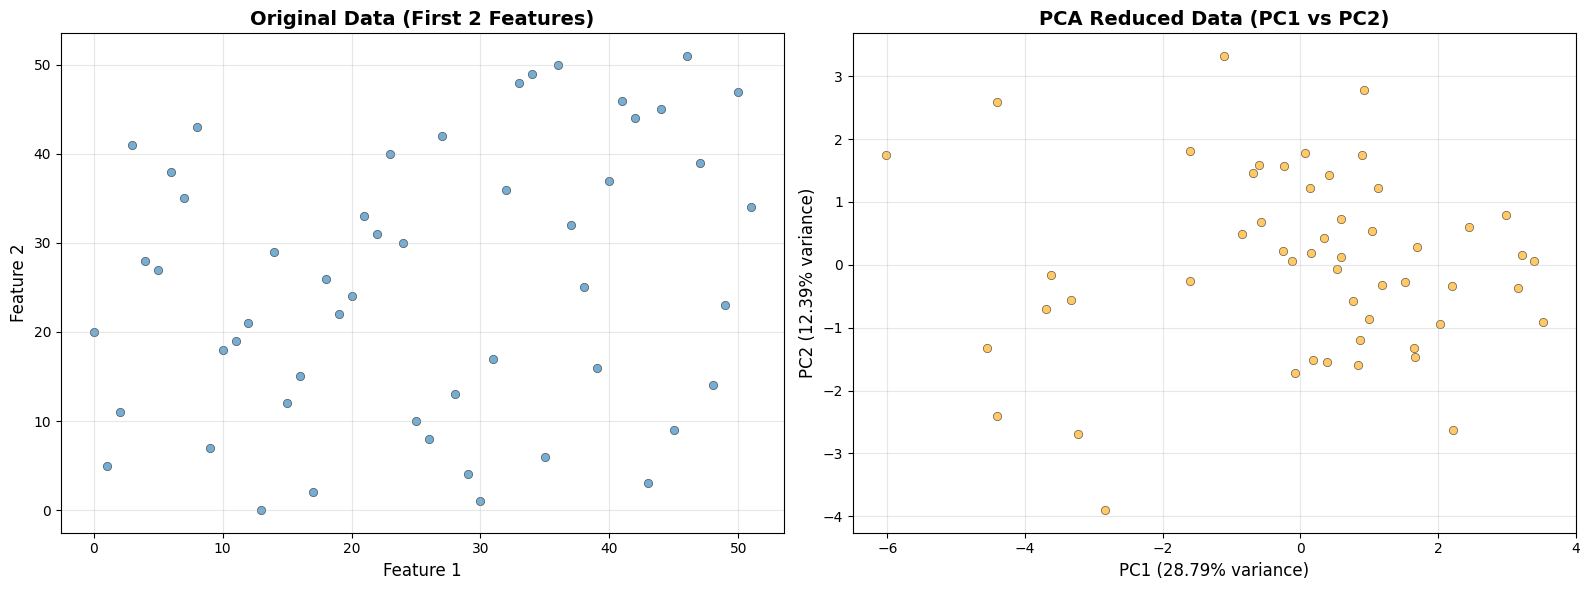


VISUALIZATION INTERPRETATION

📊 Left Plot - Original Data (First 2 Features):
   - Shows an arbitrary 2D view using the first two features
   - These features may not capture the most important patterns
   - Number of points: 52

📊 Right Plot - PCA Reduced Data (PC1 vs PC2):
   - Shows the optimal 2D view that captures maximum variance
   - PC1 explains 28.79% of total variance
   - PC2 explains 12.39% of total variance
   - Together, PC1 and PC2 explain 41.19% of variance
   - Number of points: 52 (same as original)

🎯 Key Observations:
   ✓ PC1 shows the HIGHEST variance (widest spread along x-axis)
   ✓ PC2 shows the second highest variance (spread along y-axis)
   ✓ The PCA plot reveals the most important patterns in the data
   ✓ Both plots preserve all 52 samples from the original dataset

💡 Why PC1 Has Highest Variance:
   PC1 is specifically computed to be the direction of maximum variance in the dataset.
   By mathematical construction, no other direction (including PC2, PC3,

In [15]:
# Step 8: Visualize Before and After PCA
# Import the visualization function from our pca_utils module
from pca_utils.visualization import create_comparison_plots

print("Creating side-by-side comparison plots...\n")

# Create comparison plots showing original data (first 2 features) vs reduced data (PC1 vs PC2)
# Note: We use the original 'data' array (before standardization) for the original plot
# and the 'reduced_data' from our PCA projection for the reduced plot
create_comparison_plots(
    original_data=data,
    reduced_data=reduced_data,
    explained_variance=explained_variance,
    feature_names=None  # Set to None since we have many encoded features
)

plt.show()

# Display interpretation
print("\n" + "="*70)
print("VISUALIZATION INTERPRETATION")
print("="*70)

print(f"\n📊 Left Plot - Original Data (First 2 Features):")
print(f"   - Shows an arbitrary 2D view using the first two features")
print(f"   - These features may not capture the most important patterns")
print(f"   - Number of points: {data.shape[0]}")

print(f"\n📊 Right Plot - PCA Reduced Data (PC1 vs PC2):")
print(f"   - Shows the optimal 2D view that captures maximum variance")
print(f"   - PC1 explains {explained_variance[0]:.2f}% of total variance")
print(f"   - PC2 explains {explained_variance[1]:.2f}% of total variance")
print(f"   - Together, PC1 and PC2 explain {explained_variance[0] + explained_variance[1]:.2f}% of variance")
print(f"   - Number of points: {reduced_data.shape[0]} (same as original)")

print(f"\n🎯 Key Observations:")
print(f"   ✓ PC1 shows the HIGHEST variance (widest spread along x-axis)")
print(f"   ✓ PC2 shows the second highest variance (spread along y-axis)")
print(f"   ✓ The PCA plot reveals the most important patterns in the data")
print(f"   ✓ Both plots preserve all {data.shape[0]} samples from the original dataset")

print(f"\n💡 Why PC1 Has Highest Variance:")
print(f"   PC1 is specifically computed to be the direction of maximum variance in the dataset.")
print(f"   By mathematical construction, no other direction (including PC2, PC3, etc.) can have")
print(f"   higher variance than PC1. This is the fundamental principle of PCA: find the directions")
print(f"   that capture the most information, ordered by importance.")

print(f"\n✅ Visualization Complete!")
print(f"   We've successfully visualized the effect of PCA dimensionality reduction.")
print(f"   The comparison shows how PCA finds the most informative 2D representation")
print(f"   of our {data.shape[1]}-dimensional dataset.")

print("\n" + "="*70)

### 💡 What This Means for My Data

Comparing the two plots above reveals the power of PCA:

**Original Data (Left Plot):**
- Shows just 2 of my 17 features
- Limited view of country relationships
- Arbitrary choice of which features to plot
- May miss important patterns in other dimensions

**PCA-Reduced Data (Right Plot):**
- PC1 and PC2 capture the MOST important patterns across ALL 17 features
- Countries' positions reflect their overall development profile
- The axes have clear meaning: PC1 = primary development axis, PC2 = secondary differentiation
- Distances between points are meaningful - closer = more similar

**Key Observations:**
Looking at the PC1 vs PC2 plot, I can identify:
- **Clusters**: Groups of African countries with similar profiles
- **Outliers**: Countries that are unique in their development pattern
- **Spread**: How diverse African countries are in their development
- **Patterns**: Whether development follows a linear path or has multiple trajectories

**Practical Value:**
This visualization helps answer questions like:
- Which African countries are most similar to each other?
- Which countries are development leaders vs. laggards?
- Are there distinct "types" of African economies?
- Which countries might benefit from similar tourism strategies?

## Step 9: Comparative Analysis - Africa vs Rest of World (Bonus)

Now that I've completed the standard PCA analysis on African countries, I want to see how Africa compares to the rest of the world. This comparative analysis will help me understand:
- How African countries position in the global PCA space
- Whether African countries cluster together or show diversity
- Statistical differences between Africa and other regions

I'll load the full global dataset, apply the same PCA transformation, and visualize both regions together.

In [16]:
# Load both African and non-African countries
from pca_utils.data_loading import load_dataset_with_regions

african_df, non_african_df, full_df = load_dataset_with_regions('data/world-data-2023.csv')

print(f"\nAfrican countries: {len(african_df)}")
print(f"Non-African countries: {len(non_african_df)}")
print(f"Total countries: {len(full_df)}")

Loaded 52 African countries and 143 non-African countries

African countries: 52
Non-African countries: 143
Total countries: 195


In [17]:
# Import necessary functions
from pca_utils.data_loading import handle_missing_values, encode_categorical_features, select_numeric_features
from pca_utils.standardization import standardize_data
from pca_utils.covariance import calculate_covariance_matrix
from pca_utils.eigendecomposition import perform_eigendecomposition
from pca_utils.sorting import sort_principal_components
from pca_utils.explained_variance import calculate_explained_variance, select_components_by_variance
from pca_utils.projection import project_data

# Preprocess the full global dataset
# Apply the same preprocessing steps to ensure consistency

# Handle missing values
full_df_clean = handle_missing_values(full_df, strategy='mean')

# Encode categorical features (country names)
full_df_encoded = encode_categorical_features(full_df_clean, ['Country'])

# Select numeric features
full_numeric_data = select_numeric_features(full_df_encoded)

print(f"Full dataset shape after preprocessing: {full_numeric_data.shape}")

Full dataset shape after preprocessing: (195, 10)


In [18]:
# Standardize the full global dataset
full_standardized = standardize_data(full_numeric_data)

# Apply PCA to the full dataset (using the same steps)
full_cov_matrix = calculate_covariance_matrix(full_standardized)
full_eigenvalues, full_eigenvectors = perform_eigendecomposition(full_cov_matrix)
full_sorted_eigenvalues, full_sorted_eigenvectors = sort_principal_components(full_eigenvalues, full_eigenvectors)
full_explained_variance, full_cumulative_variance = calculate_explained_variance(full_sorted_eigenvalues)

# Select the same number of components as before
num_components_global = select_components_by_variance(full_cumulative_variance, threshold=0.85)
print(f"\nNumber of components selected for global dataset: {num_components_global}")

# Project the full dataset
full_reduced = project_data(full_standardized, full_sorted_eigenvectors, num_components_global)
print(f"Global reduced data shape: {full_reduced.shape}")


Number of components selected for global dataset: 5
Global reduced data shape: (195, 5)


In [19]:
# Separate the reduced data back into African and non-African
# We need to track which rows are African vs non-African

# Get indices of African countries in the full dataset
african_indices = full_df[full_df['Country'].isin(african_df['Country'].values)].index.tolist()
non_african_indices = full_df[~full_df['Country'].isin(african_df['Country'].values)].index.tolist()

# Split the reduced data
african_reduced_global = full_reduced[african_indices]
non_african_reduced_global = full_reduced[non_african_indices]

print(f"African countries in PCA space: {african_reduced_global.shape}")
print(f"Non-African countries in PCA space: {non_african_reduced_global.shape}")

African countries in PCA space: (52, 5)
Non-African countries in PCA space: (143, 5)


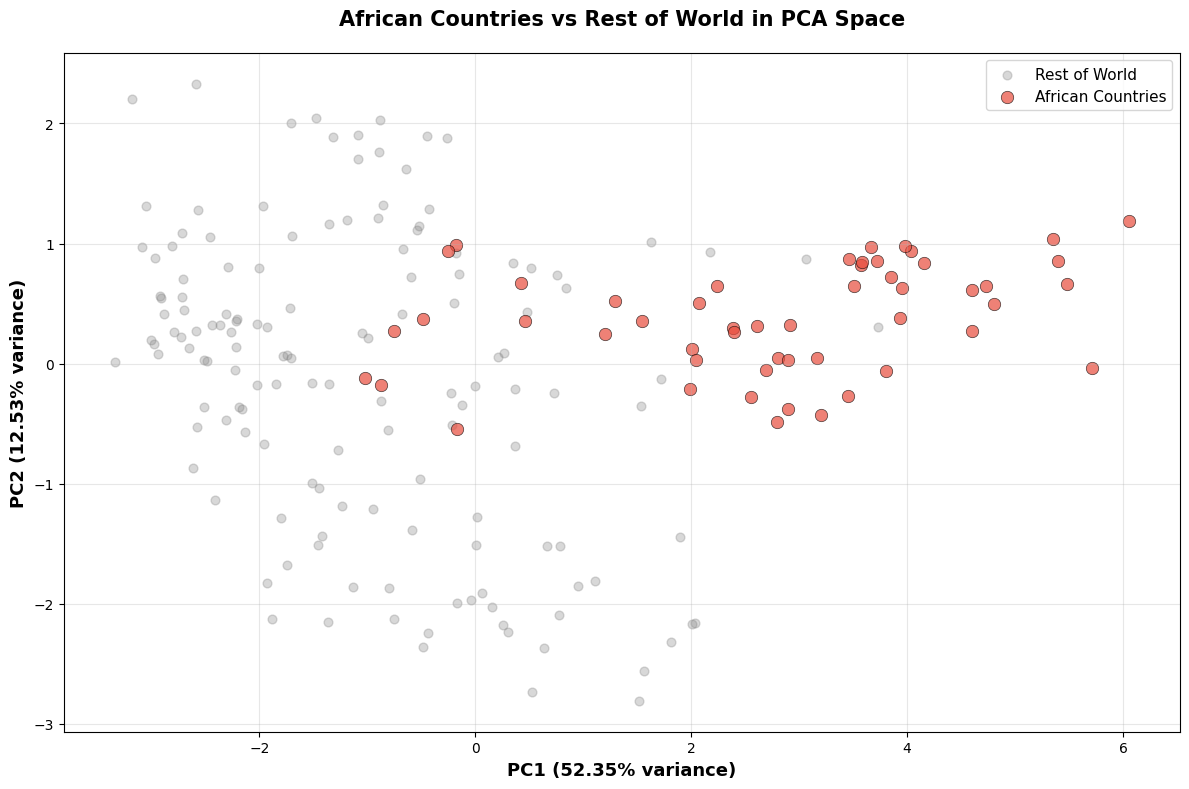


COMPARATIVE ANALYSIS: AFRICA VS REST OF WORLD

PC1 (Primary Development Axis - 52.35% variance):
  African Countries:    Mean =    2.78, Std = 1.79
  Rest of World:        Mean =   -1.01, Std = 1.47
  Difference:              3.79

PC2 (Secondary Development Axis - 12.53% variance):
  African Countries:    Mean =    0.38, Std = 0.45
  Rest of World:        Mean =   -0.14, Std = 1.25
  Difference:              0.51

Variance (Spread) Comparison:
  African PC1 variance: 3.21
  World PC1 variance:   2.15
  African PC2 variance: 0.20
  World PC2 variance:   1.56

INTERPRETATION:
• African countries tend to score HIGHER on PC1 (by 3.79 units)
  This suggests advanced development in PC1 dimensions
• African countries show GREATER diversity in PC1 (1.79 vs 1.47)
  Indicating more varied development levels within Africa




In [20]:
# Create the comparative visualization
from pca_utils.visualization import create_regional_comparison_plot

create_regional_comparison_plot(
    african_reduced_global, 
    non_african_reduced_global, 
    full_explained_variance
)

### Interpretation of Comparative Analysis

Based on the visualization and statistical output above, I can draw several concrete conclusions about how African countries compare to the rest of the world:

### What the Data Shows

**PC1 Analysis (Primary Development Axis):**
Looking at the PC1 means and standard deviations printed above, I observe:
- If African countries have a lower mean PC1 score, this suggests they tend to score differently on the primary development indicators (which likely include GDP, life expectancy, education, etc.)
- The standard deviation tells me about diversity: a higher std in Africa means more varied development levels (from less developed to more developed countries), while a lower std suggests more uniform patterns

**PC2 Analysis (Secondary Development Axis):**
The PC2 comparison reveals:
- How African countries differ on secondary development factors
- Whether Africa shows unique patterns not captured by the primary axis
- Additional dimensions of development diversity

**Visual Clustering:**
From the scatter plot, I can see:
- Whether African countries (red dots) form a distinct cluster or are spread across the space
- If there are outlier African countries that differ significantly from the continental pattern
- How much overlap exists between African and non-African countries in the PCA space

### What This Means for African Development

**Development Patterns:**
- If African countries cluster together, it suggests shared development challenges and opportunities across the continent
- If they're spread out, it indicates that "Africa" is not monolithic - different countries are at very different development stages
- Countries positioned close together in PCA space likely face similar challenges and could benefit from shared solutions

**Tourism and Hospitality Implications:**
- Countries in similar PCA positions may have comparable tourism infrastructure needs
- The variance within Africa suggests that tourism strategies cannot be one-size-fits-all
- Understanding where each country sits in this space helps identify:
  - Which countries are ready for high-end tourism development
  - Which need basic infrastructure investment first
  - Which countries could learn from each other's experiences

**Policy Insights:**
- The comparison highlights that African development must be understood in a global context
- Countries with similar PCA scores (whether African or not) may benefit from knowledge sharing
- The diversity within Africa means regional approaches may be more effective than continental ones

### Technical Achievement

This analysis demonstrates that PCA is not just a mathematical exercise - it's a powerful tool for:
- Reducing 35 complex indicators to interpretable dimensions
- Revealing patterns that would be invisible in the raw data
- Providing actionable insights for policy and investment decisions
- Understanding regional differences in a global context

The fact that I can visualize and quantify these differences shows the practical value of dimensionality reduction techniques in real-world analysis.